## Generate UMAP embeddings from data after QC and plot

In [1]:
from pathlib import Path

import pandas as pd
import umap
from plotnine import (
    aes,
    element_text,
    geom_point,
    ggplot,
    guide_legend,
    guides,
    labs,
    scale_color_brewer,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from pycytominer.cyto_utils import infer_cp_features

In [2]:
# Set constants
umap_random_seed = 0
umap_n_components = 2

# Set output directories
figure_dir = Path("./figures")
output_dir = Path("./umap_embeddings")
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

# Load in no QC normalized dataframe for CFReT example plate
QC_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected.parquet"
    )
)

# Drop any NaN rows from columns that are not metadata (contain Metadata_ prefix)
QC_df = QC_df.dropna(
    subset=[col for col in QC_df.columns if not col.startswith("Metadata_")]
).reset_index(drop=True)

# Blind treatments for UMAP visualization
# (DMSO = treatment1, TGFRi = treatment2, drug_X = treatment3)
treatment_mapping = {
    "DMSO": "treatment1",
    "TGFRi": "treatment2",
    "drug_x": "treatment3",
}
QC_df["Metadata_treatment"] = QC_df["Metadata_treatment"].map(treatment_mapping)

# Create new column for treatment cell type ID for each unique combo
QC_df["Metadata_Treatment_CellType_ID"] = (
    QC_df["Metadata_treatment"] + "_" + QC_df["Metadata_cell_type"]
)

# Print shape of the DataFrame
print(QC_df.shape)
QC_df.head()

(20865, 677)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_ER_3_03_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_03_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_PM_3_01_256,Nuclei_Texture_SumVariance_ER_3_03_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_01_256,Nuclei_Texture_SumVariance_PM_3_01_256,Metadata_Treatment_CellType_ID
0,B,2,9,failing,rejected,treatment1,221.046761,137.115493,246.602800,109.285755,...,-0.393448,0.961214,0.406068,0.374039,-0.280532,-0.158967,-0.344804,-0.263653,-0.305486,treatment1_failing
1,B,2,9,failing,rejected,treatment1,690.596142,183.067828,716.170091,177.132195,...,-0.618520,-0.050925,0.424753,0.323462,-0.096856,-0.218001,-0.359297,2.621455,-0.175679,treatment1_failing
2,B,2,9,failing,rejected,treatment1,626.561490,206.923698,623.943740,199.906440,...,-0.213998,0.492022,0.783465,0.531513,-0.515924,-0.090464,-0.381751,-0.234890,-0.312005,treatment1_failing
3,B,2,9,failing,rejected,treatment1,559.448583,220.688160,528.646623,196.955552,...,0.066951,0.233985,0.697668,0.386800,0.216837,-0.078625,-0.345897,-0.148249,-0.205381,treatment1_failing
4,B,2,9,failing,rejected,treatment1,909.019946,247.694340,897.965996,253.621836,...,0.796587,-0.833035,0.971781,0.969710,-0.859995,-0.437968,-0.375427,0.054053,-0.346036,treatment1_failing


In [3]:
# Process cp_df to separate features and metadata
cp_features = infer_cp_features(QC_df)
meta_features = infer_cp_features(QC_df, metadata=True)

# Make sure to reinitialize UMAP instance per plate
umap_fit = umap.UMAP(
    random_state=umap_random_seed, n_components=umap_n_components, n_jobs=1
)

# Fit UMAP and convert to pandas DataFrame
embeddings = pd.DataFrame(
    umap_fit.fit_transform(QC_df.loc[:, cp_features]),
    columns=[f"UMAP{x}" for x in range(0, umap_n_components)],
)
print(f"{embeddings.shape} UMAP embeddings generated")

# Combine with metadata
cp_umap_with_metadata_df = pd.concat([QC_df.loc[:, meta_features], embeddings], axis=1)

# Save UMAP with metadata DataFrame
cp_umap_with_metadata_df.to_parquet(output_dir / "post_QC_umap_embeddings.parquet")

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


(20865, 2) UMAP embeddings generated


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/facet_umap_with_QC_plot.png


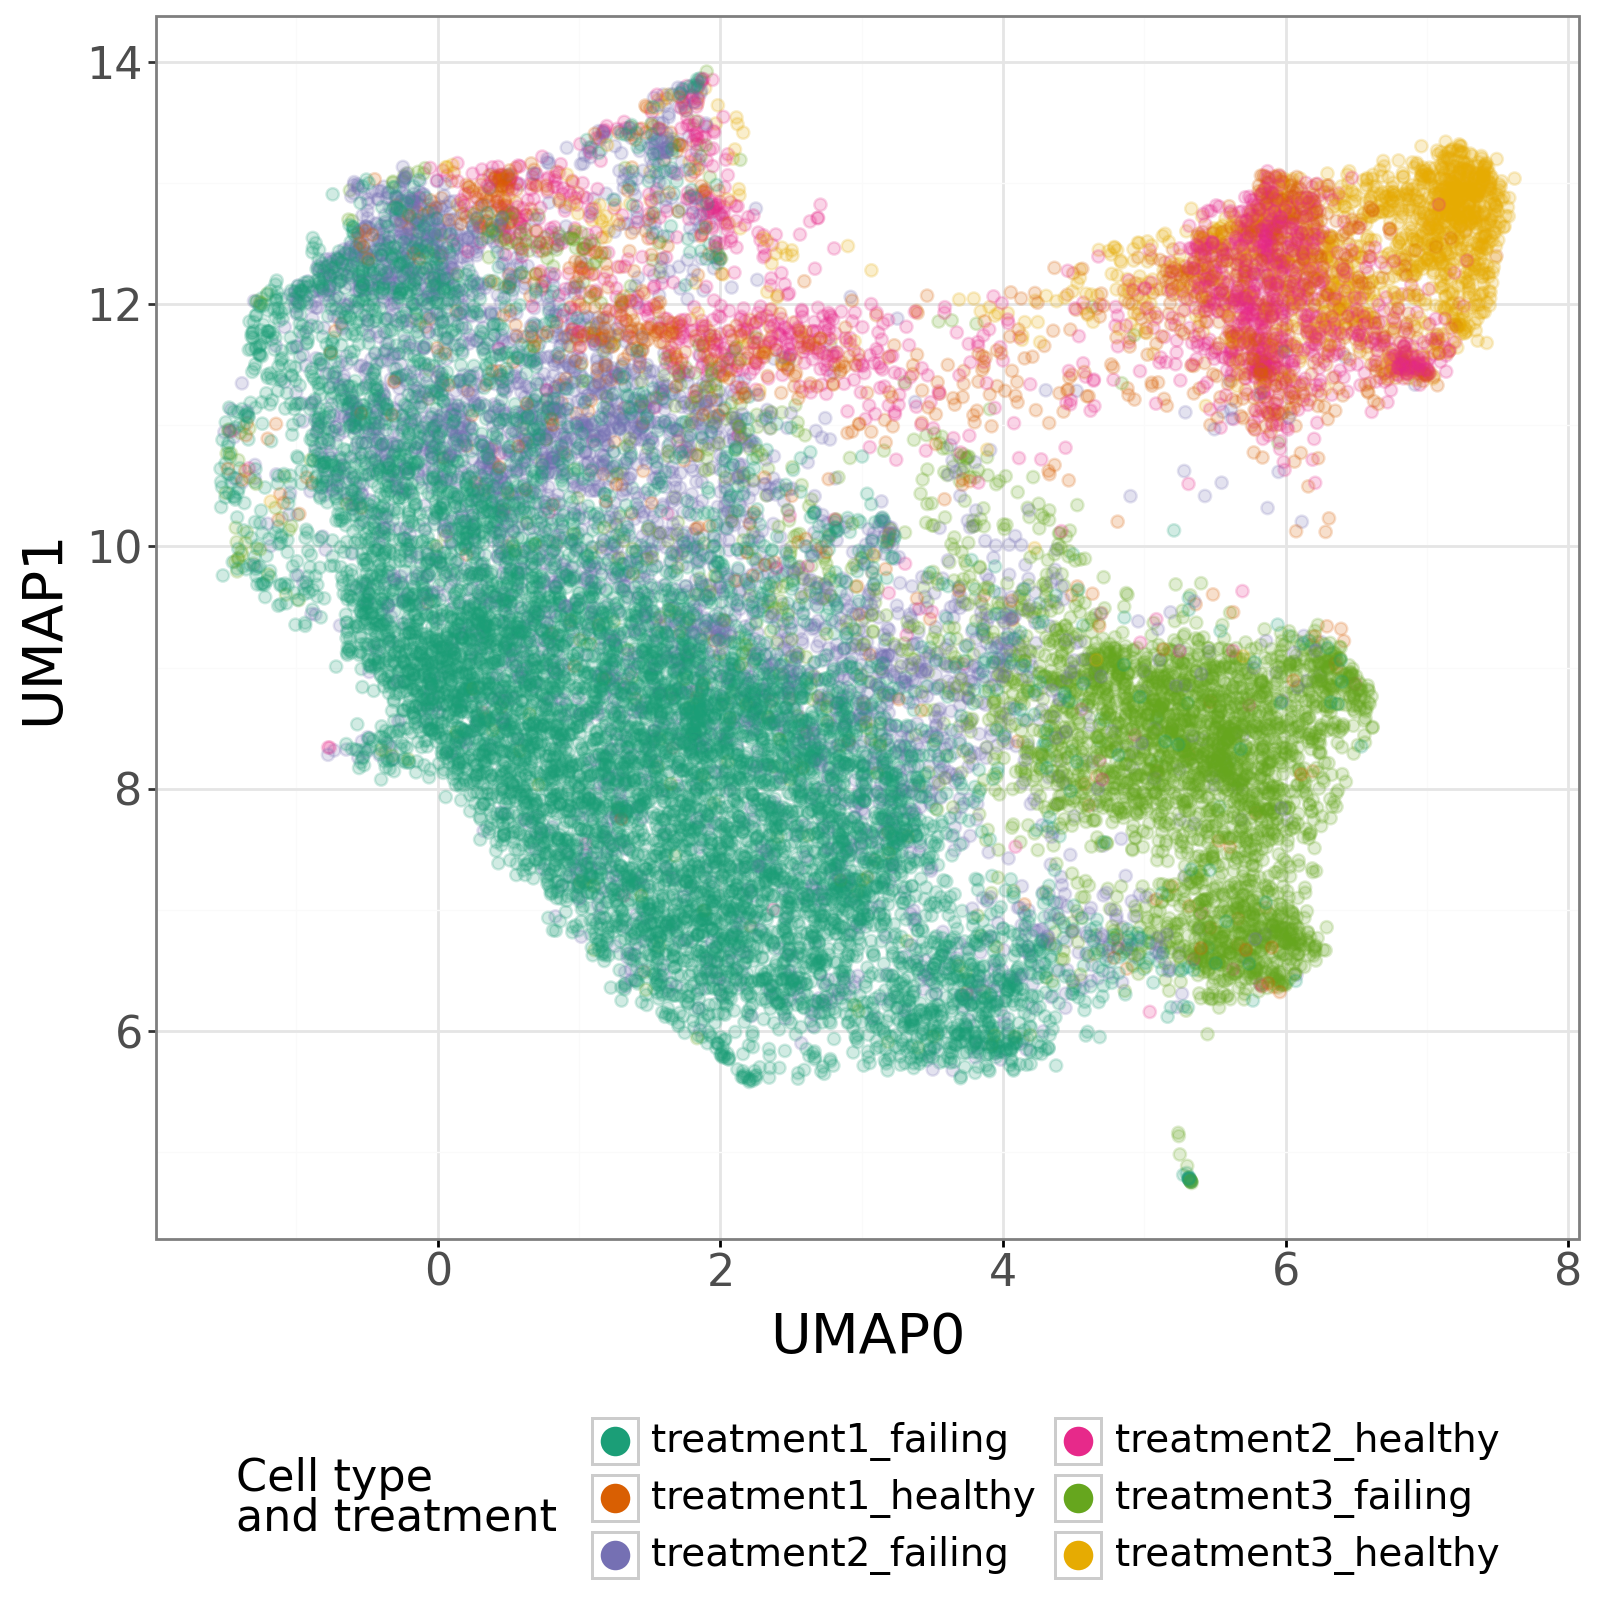

In [5]:
# Set the figure size
height = 8
width = 8
set_option("figure_size", (width, height))

# Plot with custom color palette
p = (
    ggplot(
        cp_umap_with_metadata_df,
        aes(x="UMAP0", y="UMAP1", color="Metadata_Treatment_CellType_ID"),
    )
    + labs(
        color="Cell type\nand treatment",
    )
    + geom_point(alpha=0.2, size=2)
    + theme_bw()
    + theme(
        axis_title=element_text(size=20),
        axis_text=element_text(size=16),
        legend_position="bottom",
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
    )
    + scale_color_brewer(type="qual", palette="Dark2")
    + guides(
        color=guide_legend(
            override_aes={
                "alpha": 1,
                "size": 5,
            },
            ncol=2,  # set legend columns to 2
        )
    )
)

# Save the plot
p.save(figure_dir / "facet_umap_with_QC_plot.png", dpi=400, width=width, height=height)

p.show()